# Week 2: 알고리즘 코치에 State · Memory · Control 더하기

1주차 알고리즘 코딩테스트 코치(`StateGraph` ReAct 그래프)를 그대로 가져와, 한 번 실행되고 끝나던 그래프를 상태가 유지되는 workflow로 확장했다.

1주차 대비 달라진 점

- 노트북 단일 파일을 `state.py` / `schema.py` / `tools.py` / `graph.py` 모듈로 분리 (1주차 PR 리뷰 반영)
- `InMemorySaver` checkpointer + `thread_id`로 대화 상태를 분리·복원
- 풀이 정답을 공개하기 직전 `interrupt()`로 멈춰 학습자가 *힌트만* 받을지 *전체 리뷰*를 받을지 선택 (HITL)

도구 3개(`get_algorithm_pattern`, `recommend_problems`, `review_solution`)와 응답 스키마 `ReActAnswer`는 1주차와 동일하다.

In [1]:
from langchain_core.messages import HumanMessage
from langgraph.types import Command

from graph import graph

## 그래프 구조

`agent`가 도구 호출 여부를 정하면 `route_after_agent`가 세 갈래로 나눈다.

- 도구 호출 없음 → `format_answer` (구조화 응답)
- `review_solution` 호출 포함 → `review_gate` (HITL 검토)
- 그 외 도구 호출 → `tools` (`ToolNode`)

`review_gate`는 `interrupt()`로 멈춘 뒤 선택에 따라 `tools`(전체 리뷰)나 `agent`(힌트만)로 `Command(goto=...)` 라우팅한다.

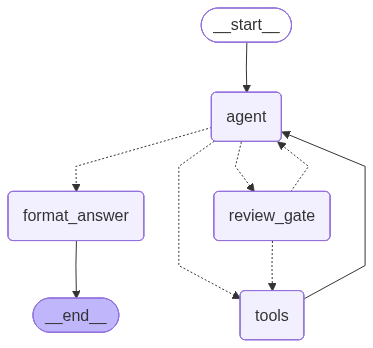

In [2]:
from IPython.display import Image

Image(filename="graph.png")

In [3]:
def show(state):
    answer = state.get("final_answer")
    if not answer:
        return
    print(f"used_tools={answer['used_tools']}  sources={answer['sources']}  confidence={answer['confidence']}")
    print(answer["answer"])


def ask(question, thread_id):
    config = {"configurable": {"thread_id": thread_id}}
    print(f"\nQ [{thread_id}]  {question}")
    print("-" * 80)
    state = graph.invoke({"messages": [HumanMessage(content=question)], "final_answer": None}, config)
    if "__interrupt__" in state:
        payload = state["__interrupt__"][0].value
        print(f"INTERRUPT · {payload['question']}  {payload['options']}")
        return
    show(state)


def resume(choice, thread_id):
    config = {"configurable": {"thread_id": thread_id}}
    print(f"resume({choice!r})")
    print("-" * 80)
    show(graph.invoke(Command(resume=choice), config))

## 1. 같은 `thread_id` — 대화 맥락을 기억한다

`alice` thread 하나로 세 질문을 이어서 던진다. 두 번째·세 번째 질문은 앞 발화에서 다룬 문제를 직접 지칭하지 않고 "방금 그 문제", "그거"로만 가리킨다. checkpointer가 이전 메시지를 복원하므로 맥락이 이어진다.

In [4]:
ask("binary-search 토픽에 Lv.3 문제 하나 추천해줘.", "alice")
ask("방금 추천한 그 문제, 핵심 접근법만 한 줄로 알려줘.", "alice")
ask("그거 풀 때 자주 하는 실수도 짚어줘.", "alice")


Q [alice]  binary-search 토픽에 Lv.3 문제 하나 추천해줘.
--------------------------------------------------------------------------------


used_tools=['recommend_problems']  sources=['pgs-43238']  confidence=0.95
Lv.3 난이도의 binary-search 토픽 문제로 "입국심사" 문제를 추천합니다. 문제 링크: https://school.programmers.co.kr/learn/courses/30/lessons/43238. 문제 설명: n명과 각 입국 심사대 처리 시간 times[]가 주어질 때, 모두 심사하기 위한 최소 시간을 구하는 문제입니다. 답이 시간 t에 대해 단조성을 가지므로 parametric binary search 기법을 사용합니다.

Q [alice]  방금 추천한 그 문제, 핵심 접근법만 한 줄로 알려줘.
--------------------------------------------------------------------------------


used_tools=['binary-search']  sources=['pgs-43238', 'binary-search']  confidence=0.9
입국심사 문제의 핵심 접근법은, 모든 심사가 끝나는 최소 시간을 이분 탐색으로 찾되, 주어진 시간 t에 대해 심사 가능한 인원 수가 n명 이상인지 단조성을 이용해 판단하는 parametric binary search입니다.

Q [alice]  그거 풀 때 자주 하는 실수도 짚어줘.
--------------------------------------------------------------------------------


used_tools=['get_algorithm_pattern']  sources=['pgs-43238', 'binary-search']  confidence=0.7
"입국심사" 문제를 풀 때 자주 하는 실수는 다음과 같습니다:

1. 이분 탐색 범위 설정 실수: 최소 시간(lo)을 0으로, 최대 시간(hi)을 충분히 큰 값(예: 가장 오래 걸리는 심사대 시간 × n)으로 정확히 잡지 않아 탐색이 제대로 이루어지지 않는 경우가 있습니다.

2. 단조성 조건 판단 오류: 주어진 시간 t에 대해 심사 가능한 인원 수를 계산할 때, n명 이상인지 정확히 비교하지 않거나, 등호 포함 여부를 헷갈려 답이 틀리는 경우가 있습니다.

3. 이분 탐색 종료 조건 혼동: lo <= hi 구간을 정확히 유지하지 않고 lo < hi로 하여 무한 루프나 오답이 발생할 수 있습니다.

4. 시간 초과 주의: 심사 가능한 인원 수 계산 시 반복문을 잘못 써서 시간 복잡도가 커지는 실수를 합니다. (times 배열을 한 번만 순회하며 계산해야 합니다.)

이 점들 유의하면 문제 해결에 도움이 됩니다.


## 2. 다른 `thread_id` — 맥락이 분리된다

`bob` thread는 위 대화를 모른다. `alice`에서 추천받은 문제를 가리켜도 무슨 문제인지 알 수 없어, 어떤 문제인지 되묻는다.

In [5]:
ask("방금 내가 추천받은 그 문제 번호가 뭐였지? 그거 다시 복습하고 싶어.", "bob")


Q [bob]  방금 내가 추천받은 그 문제 번호가 뭐였지? 그거 다시 복습하고 싶어.
--------------------------------------------------------------------------------


used_tools=[]  sources=[]  confidence=0.7
제가 이전 대화 내용을 확인해보니, 아직 문제 추천을 해드린 적이 없습니다. 어떤 주제나 난이도의 문제를 복습하고 싶으신지 알려주시면, 그에 맞는 문제를 추천해드리고 복습을 도와드릴게요!


## 3. interrupt (HITL) — 정답 공개 전에 멈춘다 · 전체 리뷰

풀이 리뷰를 요청하면 `review_gate`가 `review_solution` 호출 직전에 멈추고 선택지를 제시한다. `full`로 재개하면 레퍼런스 rubric을 받아 전체 리뷰를 작성한다.

In [6]:
review_code = '''pgs-43238 입국심사 풀이 리뷰해줘.

def solution(n, times):
    t = 0
    while True:
        t += 1
        if sum(t // x for x in times) >= n:
            return t
'''

ask(review_code, "review-full")
resume("full", "review-full")


Q [review-full]  pgs-43238 입국심사 풀이 리뷰해줘.

def solution(n, times):
    t = 0
    while True:
        t += 1
        if sum(t // x for x in times) >= n:
            return t

--------------------------------------------------------------------------------


INTERRUPT · 풀이 리뷰를 어떻게 받을까요?  {'hint': '막힌 부분 힌트만', 'full': '레퍼런스 기반 전체 리뷰'}
resume('full')
--------------------------------------------------------------------------------


used_tools=['review_solution']  sources=['pgs-43238', 'binary-search']  confidence=0.9
사용자 코드는 시간 t를 1씩 증가시키며 처리 가능한 인원 수를 계산하는 선형 탐색 방식으로, n이 매우 클 경우 시간 초과가 발생합니다. 문제의 핵심은 처리 인원 수가 시간에 대해 단조 증가하므로 이분 탐색으로 최소 시간을 찾는 것입니다. 따라서 효율적인 풀이를 위해서는 이분 탐색을 적용해 탐색 범위를 좁히는 방식으로 개선해야 합니다.


## 4. interrupt (HITL) — 힌트만

같은 요청을 `hint`로 재개하면 `review_solution`을 실행하지 않고 정답 접근을 감춘 채 방향성 힌트만 준다. `used_tools`가 비어 있는 것으로 레퍼런스를 열지 않았음을 확인할 수 있다.

In [7]:
ask(review_code, "review-hint")
resume("hint", "review-hint")


Q [review-hint]  pgs-43238 입국심사 풀이 리뷰해줘.

def solution(n, times):
    t = 0
    while True:
        t += 1
        if sum(t // x for x in times) >= n:
            return t

--------------------------------------------------------------------------------


INTERRUPT · 풀이 리뷰를 어떻게 받을까요?  {'hint': '막힌 부분 힌트만', 'full': '레퍼런스 기반 전체 리뷰'}
resume('hint')
--------------------------------------------------------------------------------


used_tools=[]  sources=['pgs-43238']  confidence=0.7
입국심사 문제는 이분 탐색을 활용하는 것이 핵심입니다. 현재 코드는 시간을 1씩 늘리며 처리 가능한 사람 수를 계산하는데, 이는 n과 times가 클 때 매우 비효율적입니다. 힌트로는 (1) 시간을 1씩 증가시키지 말고 가능한 시간 범위를 이분 탐색으로 좁혀가면서 최소 시간을 찾아보세요. (2) 중간 시간에서 처리 가능한 사람 수를 계산해 n과 비교하며 탐색 범위를 조절하는 방식을 생각해보세요.


## 5. State history — 누적된 스냅샷

`alice` thread는 매 superstep마다 상태 스냅샷이 쌓인다. time travel과 디버깅의 출발점이다.

In [8]:
history = list(graph.get_state_history({"configurable": {"thread_id": "alice"}}))
print(f"alice thread snapshots: {len(history)}")
print(f"누적 메시지 수: {len(history[0].values['messages'])}")

alice thread snapshots: 16
누적 메시지 수: 10


## 정리

- 같은 `thread_id`는 앞 발화를 복원해 "방금 그 문제" 같은 지시어를 해석하고, 다른 `thread_id`는 맥락이 분리된다.
- 제어 패턴으로 **interrupt(HITL)** 를 골랐다. 학습 코치 도메인에서 *정답 공개*는 되돌릴 수 없는 행동이라, 그 직전에 학습자가 개입할 지점을 두는 것이 자연스럽기 때문이다. 단순 패턴 조회·문제 추천은 멈추지 않는다.
- `Command(resume=...)`로 같은 thread에서 이어 실행하며, `full`/`hint` 선택이 이후 그래프 경로(`tools` vs `agent`)를 바꾼다.